# SrVO$_{3}$


SrVO$_{3}$ adopts the ideal cubic perovskite structure, with corner-sharing VO$_{6}$ octahedra and a nominal V$^{4+}$ ($3d^{1}$) configuration. The low-energy electronic structure is dominated by the V $t_{2g}$ manifold, which forms a moderately correlated metallic state. SrVO$_{3}$ is often used as a benchmark system for studying dynamical correlations because it exhibits a clear separation between coherent quasiparticle states near the Fermi level and incoherent Hubbard sidebands in photoemission experiments. While DFT correctly predicts a metallic state, it significantly overestimates the bandwidth, and it fails to reproduce the observed mass renormalization and spectral weight redistribution. Going beyond DFT with DFT+DMFT incorporates local Coulomb interactions and frequency-dependent self-energies, yielding a quantitative description of the electronic spectrum and quasiparticle properties in excellent agreement with experiment.


In this tutorial, we learn how to write a DMFT calculation for SrVO$_{3}$ using TRIQS/ModEST. Specifically, we will cover:
- a OneBodyElementsOnGrid object
- a multi-orbital embedding
- the interaction Hamiltonian factories
- the double-counting term in the DMFT loop
- writing the DMFT loop
- plotting the momentum-resolved spectral function

### 🧪 Exercise 0: Import Modest and Load the DFT data
Load the ``triqs_modest`` module and use the function ``one_body_elements_from_dft_converter`` to load the HDF5 file produced by the Wien2k DFT converter in ``ref_data/srvo3.h5``.


> 💡 **Tip:** The function ``one_body_elements_from_dft_converter`` returns the target density and the one-body elements.


Print both the target electron density and the one_body_elements, and pause for a moment, to see if this information makes sense for SrVO$_{3}$.

In [1]:
import triqs_modest as modest

target_density, obe = modest.one_body_elements_from_dft_converter("../ref_data/srvo3.h5")
print(f"target_density= {round(target_density)}e- ( 6e- x 3 O + 1e- x 1 V = 19e-)\n")
print(obe)

target_density= 19e- ( 6e- x 3 O + 1e- x 1 V = 19e-)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 21
      Represented on a fixed grid of 35 points.
      Shape of H[k_idx, σ, ν, ν'] = [35, 1, 21, 21]
      ε^σ(k) is matrix valued? = false
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 3
      Number of correlated atoms: 1
      Number of inequivalent correlated atoms = 1
      Atomic decomposition:
         dim_a:   3
             a:   0
        irreps: [1, 1, 1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [35, 1, 3, 21]
  IBZ = true
    [I]rreduicible [B]rillouin [Z]one symmetry operations from the DFT code [ibz_symmetry_ops]
      Number of symmetry ops: 48
      Number of rotations per op: 1



#### 🔎 Explanation of the OBE

We are studying SrVO$_{3}$ within a large-energy window which fully includes the hybridization between the O($2p$) and V($3d$) states. The ``OneBodyElementsOnGrid`` is composed of four pieces that represent the one-body physics obtained from DFT and will be used in the DMFT calculation.


The one-body elements (OBE) class contains four pieces:


##### 🔹 H: Band dispersion $\varepsilon^{\sigma}(k)$


This is the DFT Kohn-Sham eigenvalues: $\varepsilon^{\sigma}(k)$ is the **band energy** for spin ($\sigma$) at $k$.


##### 🔹 C_space: Local (correlated) orbital space


This describes the **correlated subspace** $\mathcal{C}$ -- the one that will be used in the DMFT impurity model. We created a projector for all three V-$t_{2g}$ orbitals and indicated we wanted to treat this atom as correlated. This is reflected in the printout: '(1) correlated atom with orbital dimension 3'.


##### 🔹 P: Downfolding projector


This is the projector that we introduced in [Tutorial 05](05s-dftdmft.ipynb). Importantly, we print the shape of the projector so that the user can confirm that this is what they expect.


##### 🔹 IBZ: Irreducible Brillouin zone Ops


Some DFT codes perform the summation in the Brillouin zone within the irreducible Brillouin zone. For those cases, to obtain observables like the local Green's function, we must symmetrize.  Internally, we read these IBZ symmetry operations and store them. We apply them whenever we perform a k-summation. In practice, there is no need to worry about them 🙂. The 48 symmetry operations correspond to the cubic space group.

## ⚛️ The role of dynamical correlations in the spectral properties of SrVO$_{3}$


Our goal is to study SrVO$_{3}$ within DFT+DMFT, where we treat the full V-$t_{2g}$ manifold as our quantum impurity, solved within DMFT using a rotationally invariant Hubbard-Kanamori interaction. All other states will be treated at the Hartree level within DFT. While we will not consider charge self-consistency in this tutorial, the workflow we develop can easily be adapted for fully charge self-consistent calculations.


Within DFT+DMFT, a double-counting term is included to account for interactions already present in DFT. SrVO$_{3}$ exhibits a hallmark three-peak spectral structure of a correlated metal: a renormalized quasiparticle peak at the Fermi level, accompanied by lower and upper Hubbard bands. We will develop a script using TRIQS/modest to reproduce this spectral function.

### 🧪 Exercise 1: Create an Embedding Description


Create an embedding from the local space in the one-body elements and print it to the screen.

In [2]:
E = modest.make_embedding(obe.C_space)
print(E)

Embedding: 1 impurities
  Σ_embed block decomposition:
    dim_α:   1   1   1
        α:   0   1   2

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1   1   1
                      γ =   0   1   2



Up until now we've only seen rather simple embeddings. However, to see the full information contained within the embedding class, use the ``description`` method to get a full print out.

In [3]:
print(E.description(True))

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1   1
        α:   0   1   2

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1   1   1
                      γ =   0   1   2
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], up_1 [1], up_2 [1], down_0 [1], down_1 [1], down_2 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  
      α = 1  |   (imp_idx = 0, γ = 1, τ = 0)    (imp_idx = 0, γ = 1, τ = 1)  
      α = 2  |   (imp_idx = 0, γ = 2, τ = 0)    (imp_idx = 0, γ = 2, τ = 1)  



#### 🔎 Explanation of Embedding

In DMFT, the **embedding** tells you how the _correlated subspace_ (from the DFT/Wannier model) is mapped to one or more **impurity problems**. Thus, it is essential to be able to flexibly construct impurity model(s) for your correlated subspace and ensure the correct assignment of local orbitals and spin channels. Below is a detailed breakdown of the printout from the ``Embedding`` object.


##### 🔹 spin index ($\sigma/\tau$) names: ["up", "down"]


These are the names of the block-diagonal spin indices $\sigma$ used in the impurity model. They correspond to the spin-up and spin-down electrons and will be used to construct the fermionic creation and annihilation operators for the impurity model.


We distinguish between:


- $\sigma$: the spin index in the **embedded problem**, and


- $\tau$: the internal spin index used by the **impurity solver** (e.g., in the impurity solver Green's function blocks).


This distinction allows us to support more generic embeddings.


##### 🔹  $\Sigma$_embed block decomposition


This section describes the **block structure** of the embedded self-energy $\Sigma_{\text{embed}}^{\sigma}(\omega)$. In our case, there are 3 orbitals each representing a $1\times1$ block in the self-energy (see $\alpha$ and dim_$\alpha$).


##### 🔹  Impurities


This describes the structure of the **impurity problems** constructed from the local space:


- ``n_imp = 0``: There is one impurity solver (index 0).


- For this impurity solver: there are 3 correlated orbitals with dimension 1 (``dim_γ``).


- The impurity Green's function will therefore have **6 blocks**: 3 for spin-up and 3 for spin-down.


The solver's block structure (``gf_struct``) is printed:


```


[imp_idx = 0] up_0 [1], up_1 [1], up_2 [1], down_0 [1], down_1 [1], down_2 [1]


```


This means:


- The impurity solver has **6 blocks**, 3 for each spin, and


- Each block is of dimension 1.


##### 🔹 Mapping ψ(α,σ) = (imp_idx, γ, τ) 


This table gives the **mapping from the embedded indices** ``(α,σ)`` to the **impurity solver indices** ``(imp_idx, γ, τ)``.


For this case, the mapping is simple: the three blocks of the impurity self-energy are directly mapped to the three blocks in the embedded self-energy. For trivial cases like this, the printing of the embedding is greatly simplified.

### 🧪 Exercise 2: Hubbard-Kanamori interaction


Create a Hubbard-Kanamori interaction for the V-$t_{2g}$ quantum impurity. TRIQS/modest provides Hamiltonian factories for different interactions. Use the function ``make_kanamori`` to construct the interaction Hamiltonian for your impurity problem and print it to the screen. Let's use $U$ = 4.6 eV, $J$ = 0.65 eV, and $U' = U - 2J$.

In [4]:
from triqs.operators import c_dag, c

U = 4.6
J = 0.65
Up = U - 2*J

h_int = modest.make_kanamori(E.sigma_names, E.imp_decomposition(0), U, Up, J)
print(h_int)

2.65*c_dag('down_0',0)*c_dag('down_1',0)*c('down_1',0)*c('down_0',0) + 2.65*c_dag('down_0',0)*c_dag('down_2',0)*c('down_2',0)*c('down_0',0) + 0.65*c_dag('down_0',0)*c_dag('up_0',0)*c('up_2',0)*c('down_2',0) + 0.65*c_dag('down_0',0)*c_dag('up_0',0)*c('up_1',0)*c('down_1',0) + 4.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0) + 3.3*c_dag('down_0',0)*c_dag('up_1',0)*c('up_1',0)*c('down_0',0) + 0.65*c_dag('down_0',0)*c_dag('up_1',0)*c('up_0',0)*c('down_1',0) + 3.3*c_dag('down_0',0)*c_dag('up_2',0)*c('up_2',0)*c('down_0',0) + 0.65*c_dag('down_0',0)*c_dag('up_2',0)*c('up_0',0)*c('down_2',0) + 2.65*c_dag('down_1',0)*c_dag('down_2',0)*c('down_2',0)*c('down_1',0) + 0.65*c_dag('down_1',0)*c_dag('up_0',0)*c('up_1',0)*c('down_0',0) + 3.3*c_dag('down_1',0)*c_dag('up_0',0)*c('up_0',0)*c('down_1',0) + 0.65*c_dag('down_1',0)*c_dag('up_1',0)*c('up_2',0)*c('down_2',0) + 4.6*c_dag('down_1',0)*c_dag('up_1',0)*c('up_1',0)*c('down_1',0) + 0.65*c_dag('down_1',0)*c_dag('up_1',0)*c('up_0',0)*c('d

## 2️⃣ Double Counting


Because we are working in a large energy window and have included the O($2p$) orbitals implicitly in the calculation, we need to properly incorporate the double-counting term, which controls the relative splitting between the correlated orbitals and the uncorrelated orbitals.  The double-counting term controls the energy difference between the V($3d$) and the O($2p$) levels. 


#### ❓ Where does the double-counting term appear in the DMFT loop


The DMFT self-consistency condition is


$$ G_{\mathrm{loc}} \overset{!}{=} G_{\mathrm{imp}},$$


which reads


$$ \sum_{k} P(k)[i\omega_{n} + \mu - H(k) - P^{\dagger}(\Sigma_{\mathrm{imp}}(i\omega_{n})-\Sigma_{\mathrm{DC}})P]^{-1}P^{\dagger}(k) = \frac{1}{ i\omega_{n} - E_{\mathrm{imp}} - \Delta(i\omega_{n})-\Sigma_{\mathrm{imp}}(i\omega_{n})},$$


In the local Green's function, it is important that we subtract off the double-counting term from the self-energy when we embed the self-energy back to the lattice. Now, let's find the definition of the impurity levels $E_{\mathrm{imp}}$. Taking the high-frequency expansion of both sides gives,


$$ \mu - \langle H(k) \rangle_{k} - \Sigma_{\infty} + \Sigma_{\mathrm{DC}}  = - E_{\mathrm{imp}} - \Sigma_{\infty},$$


and solving for $E_{\mathrm{imp}}$ gives


$$ E_{\mathrm{imp}} = \langle H(k) \rangle_{k} -\mu - \Sigma_{\mathrm{DC}}.$$


So the double-counting term appears in two places:


1. The embedded self-energy, $\Sigma_{\mathrm{embed}} = \Sigma_{\mathrm{imp}} - \Sigma_{\mathrm{DC}}$


2. The local impurity levels, which are defined as: $E_{\mathrm{imp}} = \langle H(k) \rangle_{k} -\mu - \Sigma_{\mathrm{DC}}$.

### 🧪 Exercise 3: The double-counting term


Use the double-counting utilities to set up a double-counting "solver". The double-counting term is a phenomenological term in DFT+DMFT. It can take many forms and is sometimes treated as an adjustable parameter within the framework. For our calculation, we will use the so-called "Held" double-counting formula (mean-field of the Kanamori interaction), which takes the following functional form (for 3 orbitals):


$$ \Sigma_{\mathrm{DC}} = (U - 2J)(n_{d} - \frac{1}{2}),$$


where $n$ is the total electron density of the quantum impurity.


### 🧩 Your Task


1. Use the ``DcSolver`` in ModEST to compute the double-counting term. We set it up for you. The inputs are the dimension of the $\sigma$ index, the double-counting formula to use (we choose Held), and interaction parameters $U$, $J$.


Given a Green's function, the double-counting solver computes the double-counting correction using the orbital-resolved density matrix. For SrVO$_{3}$, this amounts to a single number. Because we are not performing a charge self-consistent calculation, we will fix the double-counting term based on the DFT density. This means we will compute the local Green's function at the level of DFT and use its density matrix to evaluate the term.


2. Calculate the chemical potential.
3. Compute the local Green's function.
4. Extract the local Green's function to reshape it into its "impurity view".
5. Compute ``Sigma_DC = DcTerm.dc_self_energy(Gimp)[0][0,0]``.


Check if your result matches what you'd expect from the above equation. You should get $\Sigma_{\mathrm{DC}} \approx 4.03$ eV.

In [5]:
DcTerm = modest.DcSolver(E.n_sigma, "cHeld", U, J)

from triqs.gf import MeshImFreq

beta = 10.0
mesh = MeshImFreq(beta, S="Fermion", n_iw=250)
mu     = modest.find_chemical_potential(target_density, obe, beta, verbosity=False)
Gimp   = E.extract(modest.gloc(mesh, obe, mu))[0]
nd = Gimp.total_density().real
print(f"ρ(imp) = {nd}")
Sigma_DC = DcTerm.dc_self_energy(Gimp)[0][0,0].real
print(Sigma_DC)
print(f"(U - 2J)*(nd - 0.5)= {(U - 2*J)*(nd-0.5)}")

ρ(imp) = 1.7213635823179345
4.030499821649184
(U - 2J)*(nd - 0.5)= 4.030499821649184


Execution time: 0.0516655 seconds


## 🧠 DMFT loop

### 🧪 Exercise 4: Write the DMFT loop


The DMFT loop can be written identically to the one that you worked on in the previous tutorials. You will make a slight modification to the static part of the self-energy and the local impurity levels to incorporate the double-counting correctly.

In [6]:
import numpy as np
from triqs.gf import MeshImFreq, make_hermitian
from triqs.operators import n
from triqs_tutorials_utils.triqs_cthyb.solver import solve

# Coulomb interaction
U = 4.6
J = 0.65
Up = U-2*J

# Matsubara Mesh
mesh = MeshImFreq(beta = 10.0, S = "Fermion", n_iw = 250)

# load in density and obe
target_density, obe = modest.one_body_elements_from_dft_converter("../ref_data/srvo3.h5")

# create embedding
E = modest.make_embedding(obe.C_space)

# setup-solver parameters (realistic solver parameters: length_cycle = 5000, n_cycles = 1e+7, n_warmup_cycles = 1e+4)
solver_params = dict(length_cycle=50, n_cycles = int(1e+5),
                     n_warmup_cycles = int(1e+3), 
                     perform_tail_fit=True, fit_min_w=24,
                     fit_max_w=28, imag_threshold = 1e-6)

# make an empty self-energy
Sigma_imp_dynamic, Sigma_imp_infty = E.make_zero_imp_self_energies(mesh)[0]

# initialize the impurity self-energy to the hartree shift
for SH in Sigma_imp_infty: SH += Sigma_DC

# interaction Hamiltonian
U = 4.6
J = 0.65
Up = U - 2*J
h_int = modest.make_kanamori(E.sigma_names, E.imp_decomposition(0), U, Up, J)

# number of DMFT iterations
n_dmft_loops = 1

epsilon_d = E.extract(modest.impurity_levels(obe))[0]

for n_iter in range(n_dmft_loops):

    # 1. subtract the double counting to computed the embedded self-energy
    Sigma_imp_infty_minus_dc = [block - Sigma_DC for block in Sigma_imp_infty]

    # embed the impurity self-energy
    Sigma_C_dynamic, Sigma_C_infty = E.embed([Sigma_imp_dynamic], [Sigma_imp_infty_minus_dc])

    # find the chemical potential
    mu = modest.find_chemical_potential(target_density, obe, Sigma_C_dynamic, Sigma_C_infty, verbosity=False)

    # compute the local Green's function
    Gloc = E.extract(modest.gloc(obe, mu, Sigma_C_dynamic, Sigma_C_infty))[0]

    # Compute the effective impurity levels
    E_imp = [ block - mu - Sigma_DC for block in epsilon_d]

    # Compute hybridization function
    Delta_iw = make_hermitian(modest.hybridization(E_imp, Gloc, Sigma_imp_dynamic, Sigma_imp_infty))

    # solve the quantum impurity problem
    solver_results = solve(Delta_iw, E_imp, h_int, **solver_params)

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")

    # update the impurity self-energy
    Sigma_imp_dynamic, Sigma_imp_infty = solver_results.Sigma_dynamic, solver_results.Sigma_Hartree

Starting serial run at: 2025-08-22 14:43:14.486317



╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-4.06743*c_dag('down_0',0)*c('down_0',0) + -4.06743*c_dag('down_1',0)*c('down_1',0) + -4.06743*c_dag('down_2',0)*c('down_2',0) + -4.06743*c_dag('up_0',0)*c('up_0',0) + -4.06743*c_dag('up_1',0)*c('up_1',0) + -4.06743*c_dag('up_2',0)*c('up_2',0) + 2.65*c_dag('down_0',0)*c_dag('down_1',0)*c('down_1',0)*c('down_0',0) + 2.65*c_dag('down_0',0)*c_dag('down_2',0)*c('down_2',0)*c('down_0',0) + 0.65*c_dag('down_0',0)*c_dag('up_0',0)*c('up_2',0)*c('down_2',0) + 0.65*c_dag('down_0',0)*c_dag('up_0',0)*c('up_1',0)*c('down_1',0) + 4.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0) + 3.3*c_dag('down_0',0)*c_dag('up_1',0)*c('up_1',0)*c('down_0',0) + 0.65*c_dag('down_0',0)*c_dag('up_1',0)*c('up_0',0)*c('down_1',0) + 3.3*c_dag('down_0',0)*c_dag('up_2',0)*c('up_2',0)*c('down_0',0) + 0.65*c_dag('down_0',0)*c_dag('up_2',0)*c('up_0',0)*c('down_2',0) + 2.65*c_dag

Execution time: 0.0385964 seconds


ta_up_1_up_1: 0.00761612
  Move  Insert Delta_up_1_up_2: 0.00494139
  Move  Insert Delta_up_1_down_0: 0.0050411
  Move  Insert Delta_up_1_down_1: 0.00445523
  Move  Insert Delta_up_1_down_2: 0.00528316
  Move  Insert Delta_up_2_up_0: 0.00521264
  Move  Insert Delta_up_2_up_1: 0.00440261
  Move  Insert Delta_up_2_up_2: 0.0086476
  Move  Insert Delta_up_2_down_0: 0.00488295
  Move  Insert Delta_up_2_down_1: 0.00505775
  Move  Insert Delta_up_2_down_2: 0.00443586
  Move  Insert Delta_down_0_up_0: 0.00486434
  Move  Insert Delta_down_0_up_1: 0.00486189
  Move  Insert Delta_down_0_up_2: 0.00454824
  Move  Insert Delta_down_0_down_0: 0.00882501
  Move  Insert Delta_down_0_down_1: 0.00455409
  Move  Insert Delta_down_0_down_2: 0.00473917
  Move  Insert Delta_down_1_up_0: 0.00492468
  Move  Insert Delta_down_1_up_1: 0.00484577
  Move  Insert Delta_down_1_up_2: 0.00489184
  Move  Insert Delta_down_1_down_0: 0.00546468
  Move  Insert Delta_down_1_down_1: 0.00740105
  Move  Insert Delta_down_1_do

## 📊 Analyze Results

### 🧪 Exercise 5: Load in converged results


Now that you have your DMFT loop, we provide you with pre-converged results for this calculation at $\beta = 40.0$ 1/eV. Load the converged data from the file ``ref_data/srvo3-beta=40-U=4.6-J=0.65.h5``. Plot the self-energy from the last iteration and comment on your result. Try computing the quasiparticle renormalization $Z$ from the self-energy.

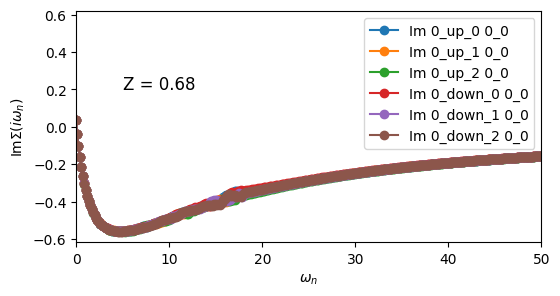

In [7]:
from h5 import HDFArchive
from triqs.plot.mpl_interface import oplot, plt
import numpy as np

with HDFArchive('../ref_data/srvo3-beta=40-U=4.6-J=0.65.h5', 'r') as ar:
    last_iter = str(len(ar)-1)
    Sigma_iw  = ar[last_iter]['Sigma_imp_list'][0]

    mu = ar[last_iter]['mu']

beta = 40.0

Z = 1/(1 - Sigma_iw['up_0'][0,0](0).imag*beta/np.pi)

plt.figure(figsize=(6,3))
oplot(Sigma_iw.imag, 'o-'); plt.text(5, 0.2, f"Z = {round(Z,2)}", fontsize=12)
plt.ylabel(r'Im$\Sigma(i\omega_{n})$')
plt.xlim(0, 50)
plt.show()

The Matsubara self-energy indicates metallic behavior with a very small scattering rate ($\mathrm{Im}\Sigma(i\omega_{n}\rightarrow 0) \rightarrow 0$). We estimate a $Z$ of 0.68, which is slightly larger than experiment, but this could be due to our choice of interaction parameters as well as our method of estimating this quantity. We see that the three V-$t_{2g}$ are degenerate as all curves collapse on top of each other as expected.

### 🧪 Exercise 6: Analytically continue the Matsubara self-energy


Now let us analytically continue the self-energy onto the real axis so that we can plot real-frequency spectra. Use the maximum entropy utilities from before to analytically continue the self-energy from the last iteration. Plot your result.

In [8]:
from triqs_tutorials_utils.maxent import Sigma_w_from_maxent

Sigma_w = Sigma_w_from_maxent(Sigma_iw, alpha_min=1e-2, alpha_max=1e2, error=0.01)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-08-22 14:45:00.225803
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.12393646154337133
scaling alpha by a factor 6151 (number of data points)
alpha[ 0] =   6.15100000e+05, chi2 =   6.93696933e+04, n_iter=       5 
alpha[ 1] =   5.09698170e+05, chi2 =   6.56194418e+04, n_iter=       3 
alpha[ 2] =   4.22357705e+05, chi2 =   6.15700631e+04, n_iter=       3 
alpha[ 3] =   3.49983659e+05, chi2 =   5.72610063e+04, n_iter=       4 
alpha[ 4] =   2.90011430e+05, chi2 =   5.27472299e+04, n_iter=       4 
alpha[ 5] =   2.40315876e+05, chi2 =   4.80977878e+04, n_iter=       4 
a

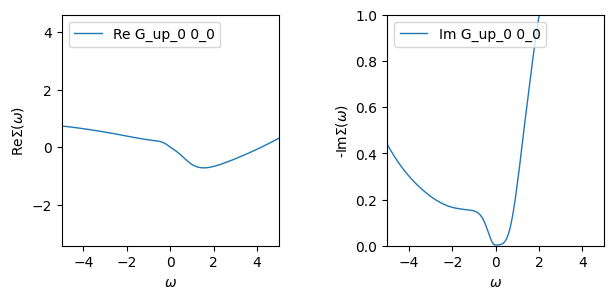

In [9]:
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
oplot(Sigma_w['up_0'] -Sigma_w['up_0'][0,0](0.0).real, axes=ax[0], mode='R', lw=1)
oplot(-Sigma_w['up_0'].imag, axes=ax[1], lw=1)
ax[0].legend(loc='upper left'); ax[1].legend(loc='upper left')
ax[0].set_xlim(-5,5); ax[1].set_ylim(0, 1); 
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 7: Compute real-frequency spectra


Now we plot the momentum-resolved spectral function along a high-symmetry path in the Brillouin zone. This is achieved by recomputing the Kohn-Sham eigenvalues and projectors along the high-symmetry path that we would like to see, and then computing the lattice Green's function along this path. The momentum-resolved spectral function corresponds to:


$$ A(\mathbf{k},\omega) = -\frac{1}{\pi}\mathrm{ImTr}G_{\nu\nu'}(\mathbf{k},\omega),$$


where the trace is over the band indices $\nu, \nu'$.



We have pre-computed the DFT data along the high-symmetry path R-$\Gamma$-X-M-$\Gamma$. This data is then converted using the Wien2kConverter (see [Tutorial 05](05s-dftdmft.ipynb) for more details).


#### 🧩 Your Task


1. Load a new one-body elements object using the function: ``one_body_elements_along_high_symmetry_path``. Print out the new obe and try to spot any differences.
2. Embed your real-frequency self-energy using the Embedding (E).
3. Use the function ``spectral_function_on_high_symmetry_path`` to compute $A(k,\omega)$.
4. Plot your result.

In [9]:
# 1. load in obe along high-symmetry path
obe2 = modest.one_body_elements_on_high_symmetry_path('../ref_data/srvo3.h5', obe)
print(obe2)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 21
      Represented on a fixed grid of 500 points.
      Shape of H[k_idx, σ, ν, ν'] = [500, 1, 21, 21]
      ε^σ(k) is matrix valued? = false
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 3
      Number of correlated atoms: 1
      Number of inequivalent correlated atoms = 1
      Atomic decomposition:
         dim_a:   3
             a:   0
        irreps: [1, 1, 1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [500, 1, 3, 21]
  IBZ = false



In [10]:
# 2. embed the self-energy
Sigma_C_w = E.embed([Sigma_w - Sigma_DC])

In [11]:
# 3. compute A(k,w)
Akw = modest.spectral_function_on_high_symmetry_path(obe2, mu, Sigma_C_w)

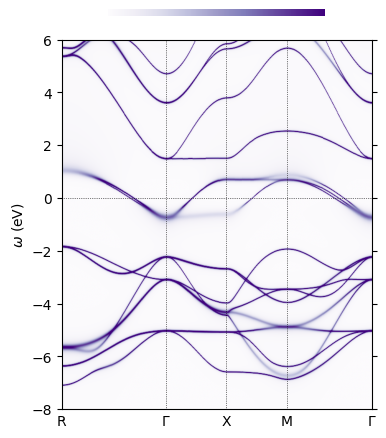

In [18]:
# 4. Plot
# matplotlib canvas and ticks
fig, ax = plt.subplots(figsize=(4,6))
ax.tick_params(right=True);ax.tick_params(which='both', axis='x', length=0)

# high-symmetry info printed in case.outband
high_kpts = [1,169,266,363,500]; high_labels = ['R', r'$\Gamma$', 'X', 'M', r'$\Gamma$']

# plot A(k,ω) using imshow
data = ax.imshow(Akw.data[0].T,origin='lower', cmap='Purples', aspect='auto', vmin=0, vmax=10, extent=(1,500, -10,10))

# create a colorbar
cbar = fig.colorbar(data, location='top', shrink=0.7, aspect=30)
cbar.set_ticks([]); cbar.outline.set_visible(False)

# decorate and set high-symmetry points
ax.set_xticks(high_kpts); ax.set_xticklabels(high_labels)
for k in high_kpts: ax.axvline(k, lw=0.5, ls='dotted', color='k')
ax.axhline(0.0, color='k', ls='dotted', lw=0.5)
ax.set_ylim(-8,6); ax.set_ylabel(r'$\omega$ (eV)')
plt.show()